In [ ]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import preprocessing, metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')


In [ ]:


def zero_crossing_rate(signal):
    signal = np.asarray(signal, dtype=float)

    if len(signal) < 2:
        return 0.0

    signs = np.sign(signal).copy()

    for i in range(1, len(signs)):
        if signs[i] == 0:
            signs[i] = signs[i - 1]

    if signs[0] == 0:
        nz = np.nonzero(signs)[0]
        if len(nz) == 0:
            return 0.0
        signs[0] = signs[nz[0]]

    return np.sum(signs[1:] != signs[:-1]) / (len(signal) - 1)



In [ ]:

def safe_corr(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    if len(a) < 2 or len(b) < 2:
        return 0.0

    if np.std(a) == 0 or np.std(b) == 0:
        return 0.0

    return float(np.corrcoef(a, b)[0, 1])



In [ ]:

def extract_window_features(window_xyz):
    x = window_xyz[:, 0]
    y = window_xyz[:, 1]
    z = window_xyz[:, 2]

    magnitude = np.sqrt(x**2 + y**2 + z**2)

    features = []

    for sig in [x, y, z, magnitude]:
        features.extend([
            np.mean(sig),
            np.std(sig),
            np.min(sig),
            np.max(sig),
            np.median(sig),
            np.percentile(sig, 25),
            np.percentile(sig, 75),
            np.sum(sig**2) / len(sig),
            zero_crossing_rate(sig),
        ])

    features.extend([
        safe_corr(x, y),
        safe_corr(x, z),
        safe_corr(y, z),
    ])

    return np.array(features, dtype=float)



In [ ]:

# -----------------------------
# 3. Extract zero-centered, smoothed, pure windows
# -----------------------------
def extract_processed_windows_from_person(
    person_id,
    window_seconds=5,
    step_seconds=2.5,
    fs=52,
    base_path="./input",
    drop_label_0=True,
    require_pure_label=True,
    center_window_samples=104,
    smoothing_samples=26,
):
    window_size = int(window_seconds * fs)
    step_size = int(step_seconds * fs)

    file_path = os.path.join(base_path, f"{person_id}.csv")

    df = pd.read_csv(
        file_path,
        names=["Sequence", "x_acceleration", "y_acceleration", "z_acceleration", "Labels"],
    )

    if drop_label_0:
        df = df[df["Labels"] != 0].copy()

    df = df.reset_index(drop=True)

    xyz = df[["x_acceleration", "y_acceleration", "z_acceleration"]].astype(float)

    local_mean = xyz.rolling(
        window=center_window_samples,
        center=True,
        min_periods=1
    ).mean()

    xyz_centered = xyz - local_mean

    xyz_smoothed = xyz_centered.rolling(
        window=smoothing_samples,
        center=True,
        min_periods=1
    ).mean()

    processed = xyz_smoothed.to_numpy(dtype=float)
    labels_all = df["Labels"].to_numpy()

    windows = []
    features = []
    labels = []

    for start in range(0, len(df) - window_size + 1, step_size):
        end = start + window_size

        window_labels = labels_all[start:end]
        unique_labels = np.unique(window_labels)

        if require_pure_label and len(unique_labels) != 1:
            continue

        label = int(unique_labels[0])
        window_xyz = processed[start:end]

        windows.append(window_xyz)
        features.append(extract_window_features(window_xyz))
        labels.append(label)

    return windows, features, labels


def extract_processed_windows_all_people(
    person_ids=range(1, 16),
    window_seconds=5,
    step_seconds=2.5,
    fs=52,
    base_path="./input",
    center_window_samples=104,
    smoothing_samples=26,
):
    all_windows = []
    all_features = []
    all_labels = []

    for pid in person_ids:
        w, f, l = extract_processed_windows_from_person(
            person_id=pid,
            window_seconds=window_seconds,
            step_seconds=step_seconds,
            fs=fs,
            base_path=base_path,
            require_pure_label=True,
            center_window_samples=center_window_samples,
            smoothing_samples=smoothing_samples,
        )

        all_windows.extend(w)
        all_features.extend(f)
        all_labels.extend(l)

    return (
        np.array(all_windows, dtype=float),
        np.array(all_features, dtype=float),
        np.array(all_labels, dtype=int),
    )


In [ ]:


# -----------------------------
# 4. Build dataset
# -----------------------------
X_seq, X_feat, raw_labels = extract_processed_windows_all_people(
    person_ids=range(1, 16),
    window_seconds=5,
    step_seconds=2.5,
    fs=52,
    base_path="./input",
    center_window_samples=104,  # 2 seconds
    smoothing_samples=26,      # 0.5 seconds
)

label_encoder = preprocessing.LabelEncoder()
y = label_encoder.fit_transform(raw_labels)

print("Sequence windows:", X_seq.shape)
print("Feature matrix:  ", X_feat.shape)
print("Labels:          ", y.shape)
print("Classes:         ", label_encoder.classes_)



Sequence windows: (14540, 260, 3)
Feature matrix:   (14540, 39)
Labels:           (14540,)
Classes:          [1 2 3 4 5 6 7]


In [ ]:


# -----------------------------
# 5. Train/test split
# -----------------------------
X_seq_train, X_seq_test, X_feat_train, X_feat_test, y_train, y_test = train_test_split(
    X_seq,
    X_feat,
    y,
    test_size=0.3,
    random_state=6758,
    stratify=y,
)


In [ ]:


# -----------------------------
# 6. Normalize sequence and feature inputs
# -----------------------------
seq_mean = X_seq_train.mean(axis=(0, 1), keepdims=True)
seq_std = X_seq_train.std(axis=(0, 1), keepdims=True) + 1e-8

X_seq_train = (X_seq_train - seq_mean) / seq_std
X_seq_test = (X_seq_test - seq_mean) / seq_std

feat_mean = X_feat_train.mean(axis=0, keepdims=True)
feat_std = X_feat_train.std(axis=0, keepdims=True) + 1e-8

X_feat_train = (X_feat_train - feat_mean) / feat_std
X_feat_test = (X_feat_test - feat_mean) / feat_std




In [ ]:

# -----------------------------
# 7. CNN-LSTM plus engineered features
# -----------------------------
def build_cnn_lstm_with_features(seq_shape, feat_shape, num_classes):
    seq_input = layers.Input(shape=seq_shape, name="sequence_input")

    x = layers.Conv1D(64, kernel_size=5, activation="relu", padding="same")(seq_input)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = layers.Conv1D(128, kernel_size=5, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = layers.Conv1D(128, kernel_size=3, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)

    x = layers.LSTM(64)(x)
    x = layers.Dropout(0.3)(x)

    feat_input = layers.Input(shape=feat_shape, name="feature_input")

    f = layers.Dense(64, activation="relu")(feat_input)
    f = layers.BatchNormalization()(f)
    f = layers.Dropout(0.3)(f)

    combined = layers.Concatenate()([x, f])

    z = layers.Dense(128, activation="relu")(combined)
    z = layers.BatchNormalization()(z)
    z = layers.Dropout(0.4)(z)

    z = layers.Dense(64, activation="relu")(z)
    z = layers.Dropout(0.3)(z)

    output = layers.Dense(num_classes, activation="softmax")(z)

    model = models.Model(
        inputs=[seq_input, feat_input],
        outputs=output
    )

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model


model = build_cnn_lstm_with_features(
    seq_shape=(X_seq_train.shape[1], X_seq_train.shape[2]),
    feat_shape=(X_feat_train.shape[1],),
    num_classes=len(np.unique(y)),
)

model.summary()




Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 260, 3)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 260, 64)   │      1,024 │ sequence_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 260, 64)   │        256 │ conv1d_6[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_4     │ (None, 130, 64)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 130, 128)  │     41,088 │ max_pooling1d_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 130, 128)  │        512 │ conv1d_7[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_5     │ (None, 65, 128)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 65, 128)   │     49,280 │ max_pooling1d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_input       │ (None, 39)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 65, 128)   │        512 │ conv1d_8[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 64)        │      2,560 │ feature_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 64)        │     49,408 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_9[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 64)        │          0 │ lstm_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 128)       │          0 │ dropout_8[0][0],  │
│ (Concatenate)       │                   │            │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 128)       │     16,512 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_10[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 128)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 170,631 (666.53 KB)

 Trainable params: 169,607 (662.53 KB)

 Non-trainable params: 1,024 (4.00 KB)

In [ ]:

# -----------------------------
# 8. Train
# -----------------------------
tf.debugging.set_log_device_placement(True)
early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=12,
    restore_best_weights=True,
)

history = model.fit(
    [X_seq_train, X_feat_train],
    y_train,
    validation_data=([X_seq_test, X_feat_test], y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1,
)


Epoch 1/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.4926 - loss: 1.5697 - val_accuracy: 0.5990 - val_loss: 1.1109
Epoch 2/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.5675 - loss: 1.2484 - val_accuracy: 0.6348 - val_loss: 1.0595
Epoch 3/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.5952 - loss: 1.1751 - val_accuracy: 0.6316 - val_loss: 1.0517
Epoch 4/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.6127 - loss: 1.1490 - val_accuracy: 0.6447 - val_loss: 1.0288
Epoch 5/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.6246 - loss: 1.1041 - val_accuracy: 0.6442 - val_loss: 1.0220
Epoch 6/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.6242 - loss: 1.0990 - val_accuracy: 0.6465 - val_loss: 1.0127
Epoch 7/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.6291 - loss: 1.0763 - val_accuracy: 0.6499 - val_loss: 1.0031
Epoch 8/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.6318 - loss: 1.0697 -

137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
CNN-LSTM plus features accuracy: 0.7184777624942686

              precision    recall  f1-score   support

           0       0.72      0.82      0.77      1398
           1       0.46      0.12      0.19       102
           2       0.47      0.18      0.25       473
           3       0.90      0.90      0.90       816
           4       0.61      0.43      0.50       110
           5       0.69      0.24      0.35       101
           6       0.67      0.79      0.72      1362

    accuracy                           0.72      4362
   macro avg       0.64      0.50      0.53      4362
weighted avg       0.70      0.72      0.69      4362



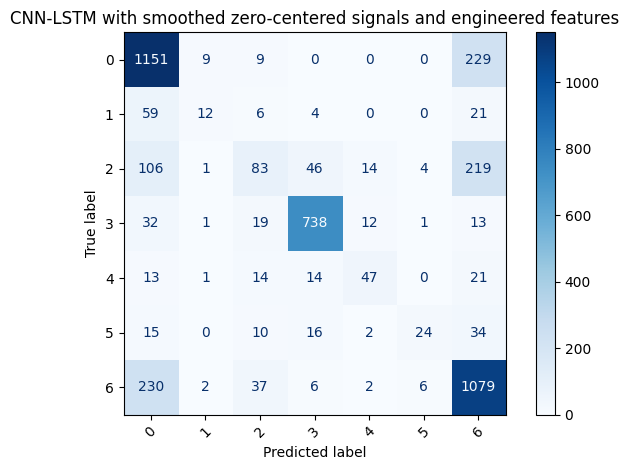

In [ ]:

# -----------------------------
# 9. Evaluate
# -----------------------------
y_pred = np.argmax(model.predict([X_seq_test, X_feat_test]), axis=1)

print("CNN-LSTM plus features accuracy:", metrics.accuracy_score(y_test, y_pred))
print()
print(metrics.classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues",
    xticks_rotation=45,
)

plt.title("CNN-LSTM with smoothed zero-centered signals and engineered features")
plt.tight_layout()
plt.show()



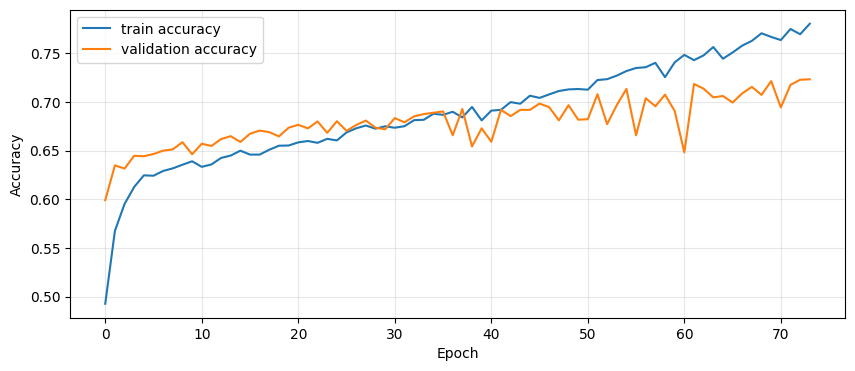

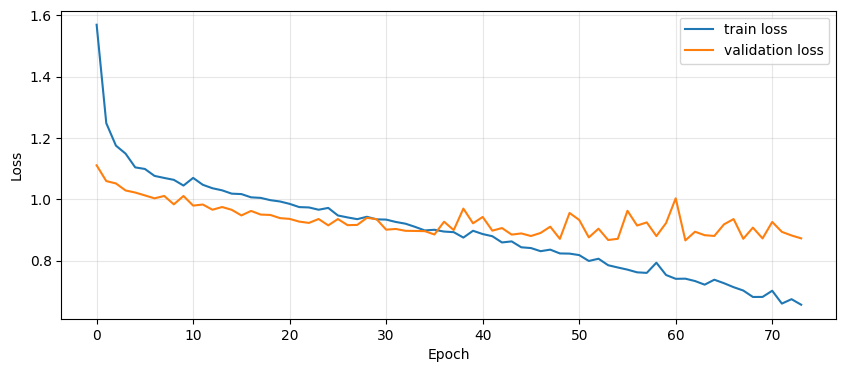

In [ ]:


# -----------------------------
# 10. Training curves
# -----------------------------
plt.figure(figsize=(10, 4))
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()